# CT Lung Cancer Detection — Progress Report

**Task:** 4-class CT image classification  
**Classes:** Adenocarcinoma · Squamous Cell Carcinoma · Large Cell Carcinoma · Normal  
**Dataset:** 988 PNG CT slices (601 train / 72 valid / 315 test)  
**Framework:** PyTorch + timm  
**Scope:** MS Thesis

---
**Contents**
1. Setup & Data Loading
2. Dataset Overview
3. Data Validation
4. Experiment Configurations
5. Training Curves
6. Evaluation Results
7. Grad-CAM Explainability
8. Summary & Next Steps

## 1. Setup & Data Loading

In [1]:
import sys, json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import yaml
from PIL import Image

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

# Project root is the notebook directory
ROOT = Path('.')
sys.path.insert(0, str(ROOT))

from tools.data.class_map import CLASSES, CLASS_TO_IDX, DISPLAY_NAMES, TRAIN_FOLDER_MAP

# Load experiment data
with open(ROOT / 'models/baseline_v1.json') as f:
    run1_meta = json.load(f)
with open(ROOT / 'models/efficientnet_focal_v1.json') as f:
    run2_meta = json.load(f)
with open(ROOT / 'reports/eval_baseline_v1.json') as f:
    run1_eval = json.load(f)
with open(ROOT / 'reports/eval_efficientnet_focal_v1.json') as f:
    run2_eval = json.load(f)
with open(ROOT / 'experiments/efficientnet_focal_v1/gradcam/gradcam_summary.json') as f:
    gradcam_summary = json.load(f)
with open(ROOT / 'args/train.yaml') as f:
    cfg = yaml.safe_load(f)

DISPLAY = [DISPLAY_NAMES[c] for c in CLASSES]
COLORS = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
print('All artifacts loaded successfully.')

All artifacts loaded successfully.


## 2. Dataset Overview

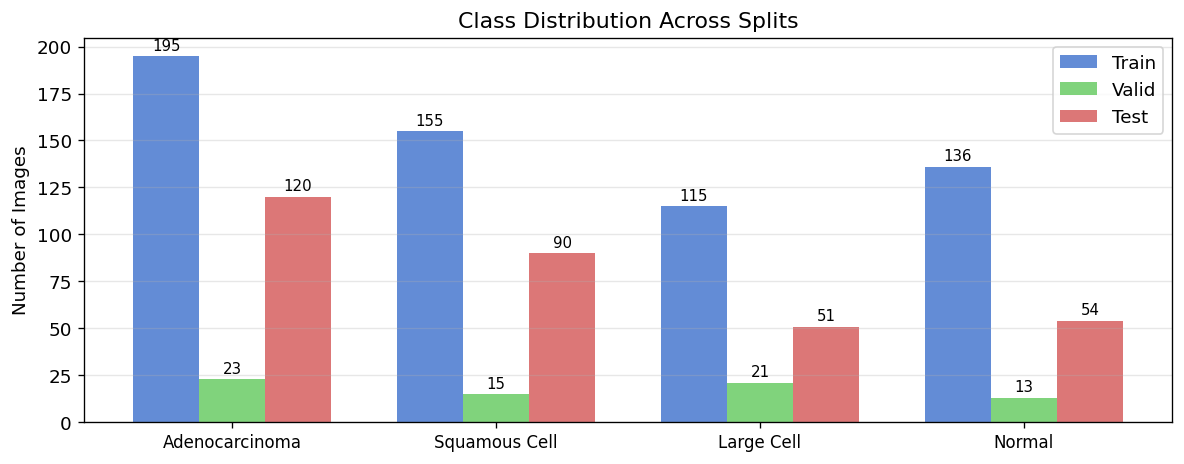


Class                           Train  Valid   Test   Total
----------------------------------------------------------
Adenocarcinoma                    195     23    120     338
Squamous Cell                     155     15     90     260
Large Cell                        115     21     51     187
Normal                            136     13     54     203
----------------------------------------------------------
TOTAL                             601     72    315     988


In [2]:
# Class distribution across splits
from tools.training.dataset import CTLungDataset, compute_class_weights

train_ds = CTLungDataset('Data-2', 'train', 224, cfg)
valid_ds = CTLungDataset('Data-2', 'valid', 224, cfg)
test_ds  = CTLungDataset('Data-2', 'test',  224, cfg)

splits = {'Train': train_ds, 'Valid': valid_ds, 'Test': test_ds}
counts = {split: [ds.class_counts[c] for c in CLASSES] for split, ds in splits.items()}

# Bar chart
x = np.arange(len(CLASSES))
width = 0.25
fig, ax = plt.subplots(figsize=(10, 4))
for i, (split, cnt) in enumerate(counts.items()):
    bars = ax.bar(x + i * width, cnt, width, label=split, color=['#4878CF','#6ACC65','#D65F5F'][i], alpha=0.85)
    for bar, v in zip(bars, cnt):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5, str(v),
                ha='center', va='bottom', fontsize=9)
ax.set_xticks(x + width)
ax.set_xticklabels(DISPLAY, fontsize=10)
ax.set_ylabel('Number of Images')
ax.set_title('Class Distribution Across Splits')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Summary table
print(f'\n{"Class":<30} {"Train":>6} {"Valid":>6} {"Test":>6} {"Total":>7}')
print('-' * 58)
for i, (cls, disp) in enumerate(zip(CLASSES, DISPLAY)):
    t, v, te = counts['Train'][i], counts['Valid'][i], counts['Test'][i]
    print(f'{disp:<30} {t:>6} {v:>6} {te:>6} {t+v+te:>7}')
print('-' * 58)
print(f'{"TOTAL":<30} {sum(counts["Train"]):>6} {sum(counts["Valid"]):>6} {sum(counts["Test"]):>6} {988:>7}')

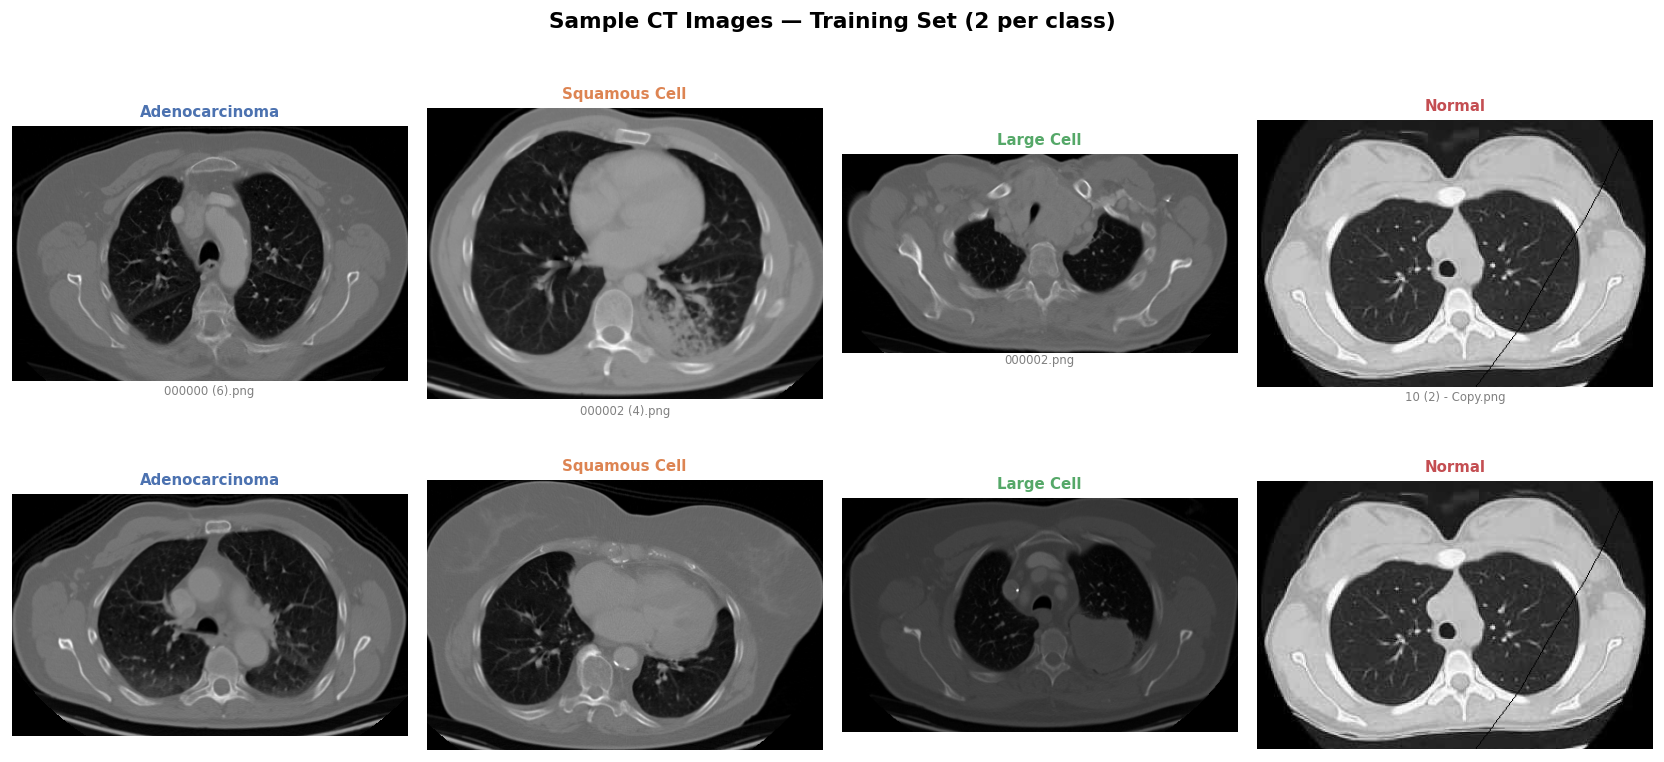

In [3]:
# Sample images: 2 per class from training set
data_root = ROOT / 'Data-2' / 'train'
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle('Sample CT Images — Training Set (2 per class)', fontsize=13, fontweight='bold')

for col, (folder, canonical) in enumerate(TRAIN_FOLDER_MAP.items()):
    folder_path = data_root / folder
    images = sorted(folder_path.glob('*.png'))[:2]
    for row, img_path in enumerate(images):
        ax = axes[row][col]
        img = Image.open(img_path).convert('RGB')
        ax.imshow(img, cmap='gray')
        ax.set_title(DISPLAY_NAMES[canonical], fontsize=9, fontweight='bold', color=COLORS[col])
        ax.axis('off')
        if row == 0:
            ax.text(0.5, -0.05, img_path.name, transform=ax.transAxes,
                    ha='center', fontsize=7, color='gray')

plt.tight_layout()
plt.show()

In [4]:
# Class weights for weighted loss
weights = compute_class_weights(train_ds)
print('Class Weights (Weighted CrossEntropyLoss / FocalLoss):')
print(f'{"Class":<30} {"Train Count":>12} {"Weight":>10}')
print('-' * 55)
for disp, cls, w in zip(DISPLAY, CLASSES, weights.tolist()):
    cnt = train_ds.class_counts[cls]
    print(f'{disp:<30} {cnt:>12} {w:>10.4f}')
print('\nHigher weight = model penalised more for misclassifying that class.')

Class Weights (Weighted CrossEntropyLoss / FocalLoss):
Class                           Train Count     Weight
-------------------------------------------------------
Adenocarcinoma                          195     0.7705
Squamous Cell                           155     0.9694
Large Cell                              115     1.3065
Normal                                  136     1.1048

Higher weight = model penalised more for misclassifying that class.


## 3. Data Validation

In [5]:
import subprocess, sys
result = subprocess.run(
    [sys.executable, 'tools/data/validate_data.py'],
    capture_output=True, text=True
)
print(result.stdout)
if result.returncode != 0:
    print('STDERR:', result.stderr[-500:])

CT Lung Cancer Dataset Validation

[TRAIN] — 601 images
  adenocarcinoma                  195   32.4%  ████████████████
  squamous_cell_carcinoma         155   25.8%  ████████████
  large_cell_carcinoma            115   19.1%  █████████
  normal                          136   22.6%  ███████████

[VALID] — 72 images
  adenocarcinoma                   23   31.9%  ███████████████
  squamous_cell_carcinoma          15   20.8%  ██████████
  large_cell_carcinoma             21   29.2%  ██████████████
  normal                           13   18.1%  █████████

[TEST] — 315 images
  adenocarcinoma                  120   38.1%  ███████████████████
  squamous_cell_carcinoma          90   28.6%  ██████████████
  large_cell_carcinoma             51   16.2%  ████████
  normal                           54   17.1%  ████████

[LEAKAGE CHECK] Train vs Test patient overlap

[CLASS WEIGHTS] (for weighted CrossEntropyLoss)
  adenocarcinoma                  count=195  weight=0.7705
  squamous_cell_carcinoma 

> **Note on Patient-Level Leakage:** The pre-defined split was made at the CT **slice level**, not the **patient level**. 22 patients have slices in both `train/` and `test/`. This is the **standard published split** for this dataset — using it maintains comparability with existing literature. Documented as a thesis limitation.

## 4. Experiment Configurations

In [6]:
import pandas as pd

r1cfg = run1_meta['config']
r2cfg = run2_meta['config']

config_rows = [
    ('Backbone',           r1cfg['model']['backbone'],          r2cfg['model']['backbone']),
    ('Pretrained',         str(r1cfg['model']['pretrained']),   str(r2cfg['model']['pretrained'])),
    ('Dropout',            r1cfg['model']['dropout'],           r2cfg['model']['dropout']),
    ('Loss function',      r1cfg['training']['loss'],           r2cfg['training']['loss']),
    ('Focal gamma',        '—',                                 r2cfg['training'].get('focal_gamma','—')),
    ('Learning rate',      r1cfg['training']['lr'],             r2cfg['training']['lr']),
    ('Batch size',         r1cfg['training']['batch_size'],     r2cfg['training']['batch_size']),
    ('Scheduler',          r1cfg['training']['scheduler'],      r2cfg['training']['scheduler']),
    ('Early stop patience',r1cfg['training']['early_stopping_patience'], r2cfg['training']['early_stopping_patience']),
    ('Image size',         r1cfg['data']['image_size'],         r2cfg['data']['image_size']),
    ('Rotation aug',       r1cfg['augmentation']['random_rotation'], r2cfg['augmentation']['random_rotation']),
    ('Seed',               r1cfg['training']['seed'],           r2cfg['training']['seed']),
]

df = pd.DataFrame(config_rows, columns=['Parameter', 'Run 1 — ResNet-50', 'Run 2 — EfficientNet-B0'])
df = df.set_index('Parameter')

# Highlight rows that differ
def highlight_diff(row):
    return ['background-color: #fff3cd' if row.iloc[0] != row.iloc[1] else '' for _ in row]

df.style.apply(highlight_diff, axis=1).set_caption('Highlighted rows differ between runs')

,Run 1 — ResNet-50,Run 2 — EfficientNet-B0
Parameter,,
Backbone,resnet50,efficientnet_b0
Pretrained,True,True
Dropout,0.500000,0.400000
Loss function,weighted_ce,focal
Focal gamma,—,2.000000
Learning rate,0.000100,0.000100
Batch size,32,32
Scheduler,cosine,cosine
Early stop patience,7,10


## 5. Training Curves

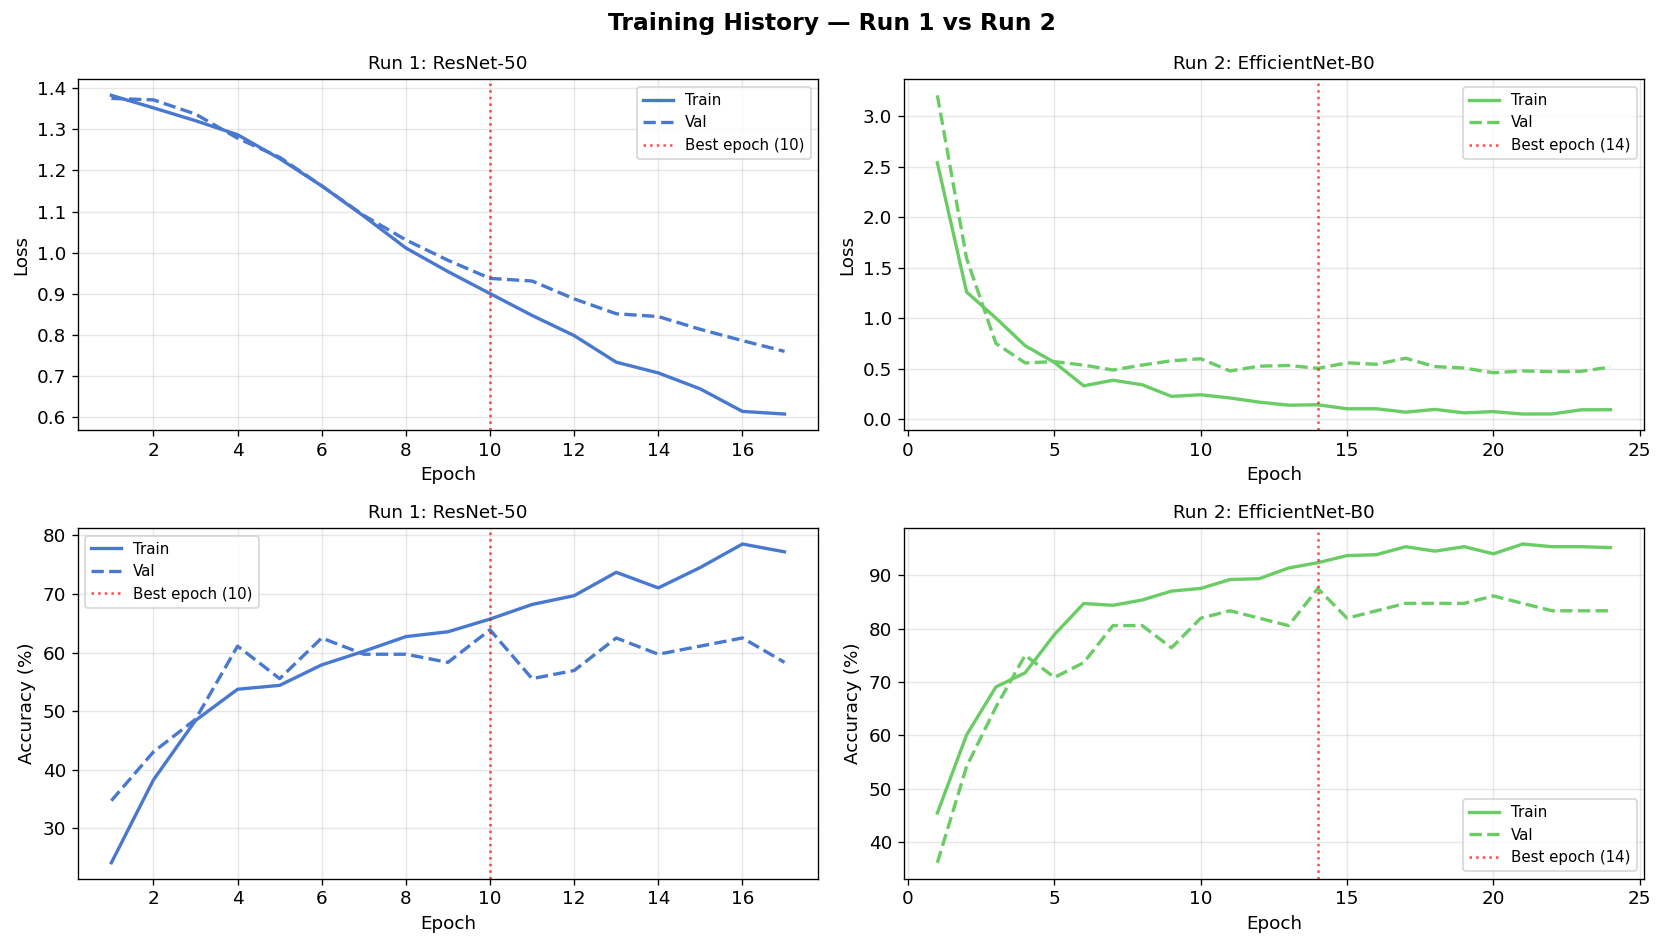

Run 1 — Best val acc: 63.89% at epoch 10  |  Trained for 17 epochs
Run 2 — Best val acc: 87.50% at epoch 14  |  Trained for 24 epochs


In [7]:
h1 = run1_meta['history']
h2 = run2_meta['history']
best1 = run1_meta['epochs_trained']
best2 = run2_meta['epochs_trained']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Training History — Run 1 vs Run 2', fontsize=14, fontweight='bold')

configs = [
    (axes[0][0], h1, 'train_loss', 'val_loss',  'Loss',     'Run 1: ResNet-50', best1, '#4878CF'),
    (axes[0][1], h2, 'train_loss', 'val_loss',  'Loss',     'Run 2: EfficientNet-B0', best2, '#6ACC65'),
    (axes[1][0], h1, 'train_acc',  'val_acc',   'Accuracy', 'Run 1: ResNet-50', best1, '#4878CF'),
    (axes[1][1], h2, 'train_acc',  'val_acc',   'Accuracy', 'Run 2: EfficientNet-B0', best2, '#6ACC65'),
]

for ax, h, train_k, val_k, ylabel, title, best_ep, color in configs:
    epochs = range(1, len(h[train_k]) + 1)
    train_vals = h[train_k]
    val_vals   = h[val_k]
    if 'acc' in train_k:
        train_vals = [v * 100 for v in train_vals]
        val_vals   = [v * 100 for v in val_vals]
    ax.plot(epochs, train_vals, label='Train', linewidth=2, color=color)
    ax.plot(epochs, val_vals,   label='Val',   linewidth=2, color=color, linestyle='--')
    ax.axvline(best_ep, color='red', linestyle=':', alpha=0.7, label=f'Best epoch ({best_ep})')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel + (' (%)' if 'acc' in train_k else ''))
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Run 1 — Best val acc: {run1_meta["best_val_acc"]:.2%} at epoch {best1}  |  Trained for {len(h1["val_acc"])} epochs')
print(f'Run 2 — Best val acc: {run2_meta["best_val_acc"]:.2%} at epoch {best2}  |  Trained for {len(h2["val_acc"])} epochs')

## 6. Evaluation Results

In [8]:
# Side-by-side per-class metrics
metrics = ['precision', 'recall', 'f1-score']

rows = []
for disp in DISPLAY:
    r1 = run1_eval['classification_report'][disp]
    r2 = run2_eval['classification_report'][disp]
    rows.append([
        disp,
        f'{r1["precision"]:.3f}', f'{r1["recall"]:.3f}', f'{r1["f1-score"]:.3f}',
        f'{r2["precision"]:.3f}', f'{r2["recall"]:.3f}', f'{r2["f1-score"]:.3f}',
    ])

cols = pd.MultiIndex.from_tuples([
    ('', 'Class'),
    ('Run 1: ResNet-50', 'Precision'), ('Run 1: ResNet-50', 'Recall'), ('Run 1: ResNet-50', 'F1'),
    ('Run 2: EfficientNet-B0', 'Precision'), ('Run 2: EfficientNet-B0', 'Recall'), ('Run 2: EfficientNet-B0', 'F1'),
])
df_metrics = pd.DataFrame(rows, columns=cols)
df_metrics = df_metrics.set_index(('', 'Class'))

# Macro averages row
r1_macro = run1_eval['classification_report']['macro avg']
r2_macro = run2_eval['classification_report']['macro avg']
macro_row = pd.DataFrame([[
    f'{r1_macro["precision"]:.3f}', f'{r1_macro["recall"]:.3f}', f'{r1_macro["f1-score"]:.3f}',
    f'{r2_macro["precision"]:.3f}', f'{r2_macro["recall"]:.3f}', f'{r2_macro["f1-score"]:.3f}',
]], columns=df_metrics.columns, index=['Macro Avg'])
df_metrics = pd.concat([df_metrics, macro_row])

display(df_metrics.style
    .set_caption(f'Run 1 Test Accuracy: {run1_eval["test_accuracy"]:.2%}   |   Run 2 Test Accuracy: {run2_eval["test_accuracy"]:.2%}')
    .set_table_styles([{'selector': 'th', 'props': [('background-color', '#f0f0f0')]}])
)

print(f'\nKey improvement — Adenocarcinoma Recall:')
r1_adeno = run1_eval['classification_report']['Adenocarcinoma']['recall']
r2_adeno = run2_eval['classification_report']['Adenocarcinoma']['recall']
print(f'  Run 1: {r1_adeno:.1%}  →  Run 2: {r2_adeno:.1%}  (+{r2_adeno - r1_adeno:.1%})')


Key improvement — Adenocarcinoma Recall:
  Run 1: 1.7%  →  Run 2: 50.8%  (+49.2%)


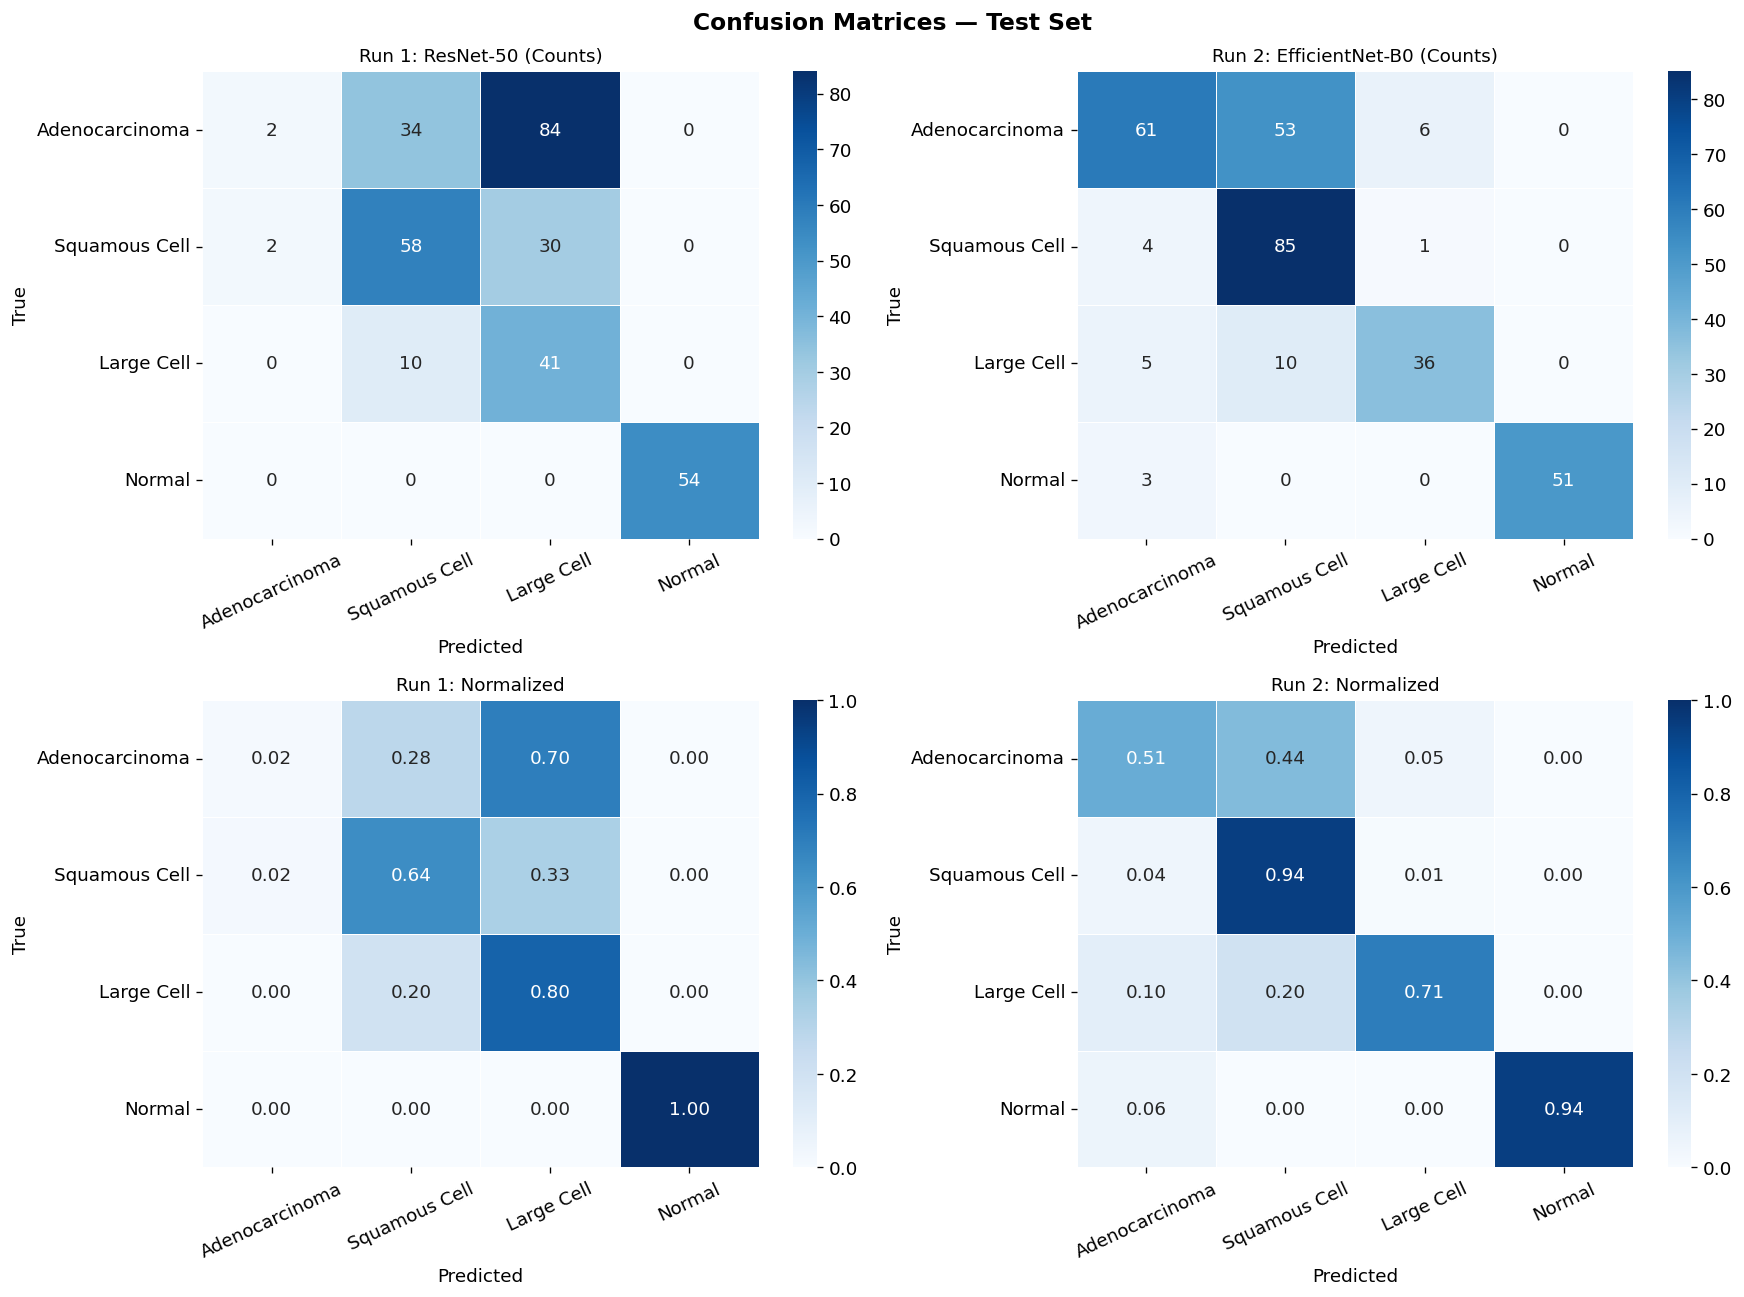

Main confusion pattern (Run 2): Adenocarcinoma ↔ Squamous Cell (53/120 adeno misclassified as squamous)


In [9]:
# Confusion matrices side by side
cm1 = np.array(run1_eval['confusion_matrix'])
cm2 = np.array(run2_eval['confusion_matrix'])

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('Confusion Matrices — Test Set', fontsize=14, fontweight='bold')

titles = [
    ('Run 1: ResNet-50 (Counts)',      cm1, 'd',   False),
    ('Run 2: EfficientNet-B0 (Counts)',cm2, 'd',   False),
    ('Run 1: Normalized',              cm1, '.2f', True),
    ('Run 2: Normalized',              cm2, '.2f', True),
]

for ax, (title, cm, fmt, norm) in zip(axes.flat, titles):
    data = cm.astype(float) / cm.sum(axis=1, keepdims=True) if norm else cm
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues', ax=ax,
                xticklabels=DISPLAY, yticklabels=DISPLAY,
                linewidths=0.5, vmin=0, vmax=(1 if norm else None))
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=25)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

print('Main confusion pattern (Run 2): Adenocarcinoma ↔ Squamous Cell (53/120 adeno misclassified as squamous)')

## 7. Grad-CAM Explainability

Grad-CAM heatmaps highlight the CT regions the model focused on when making its prediction.  
All samples below are **misclassified** validation images — showing where the model goes wrong.

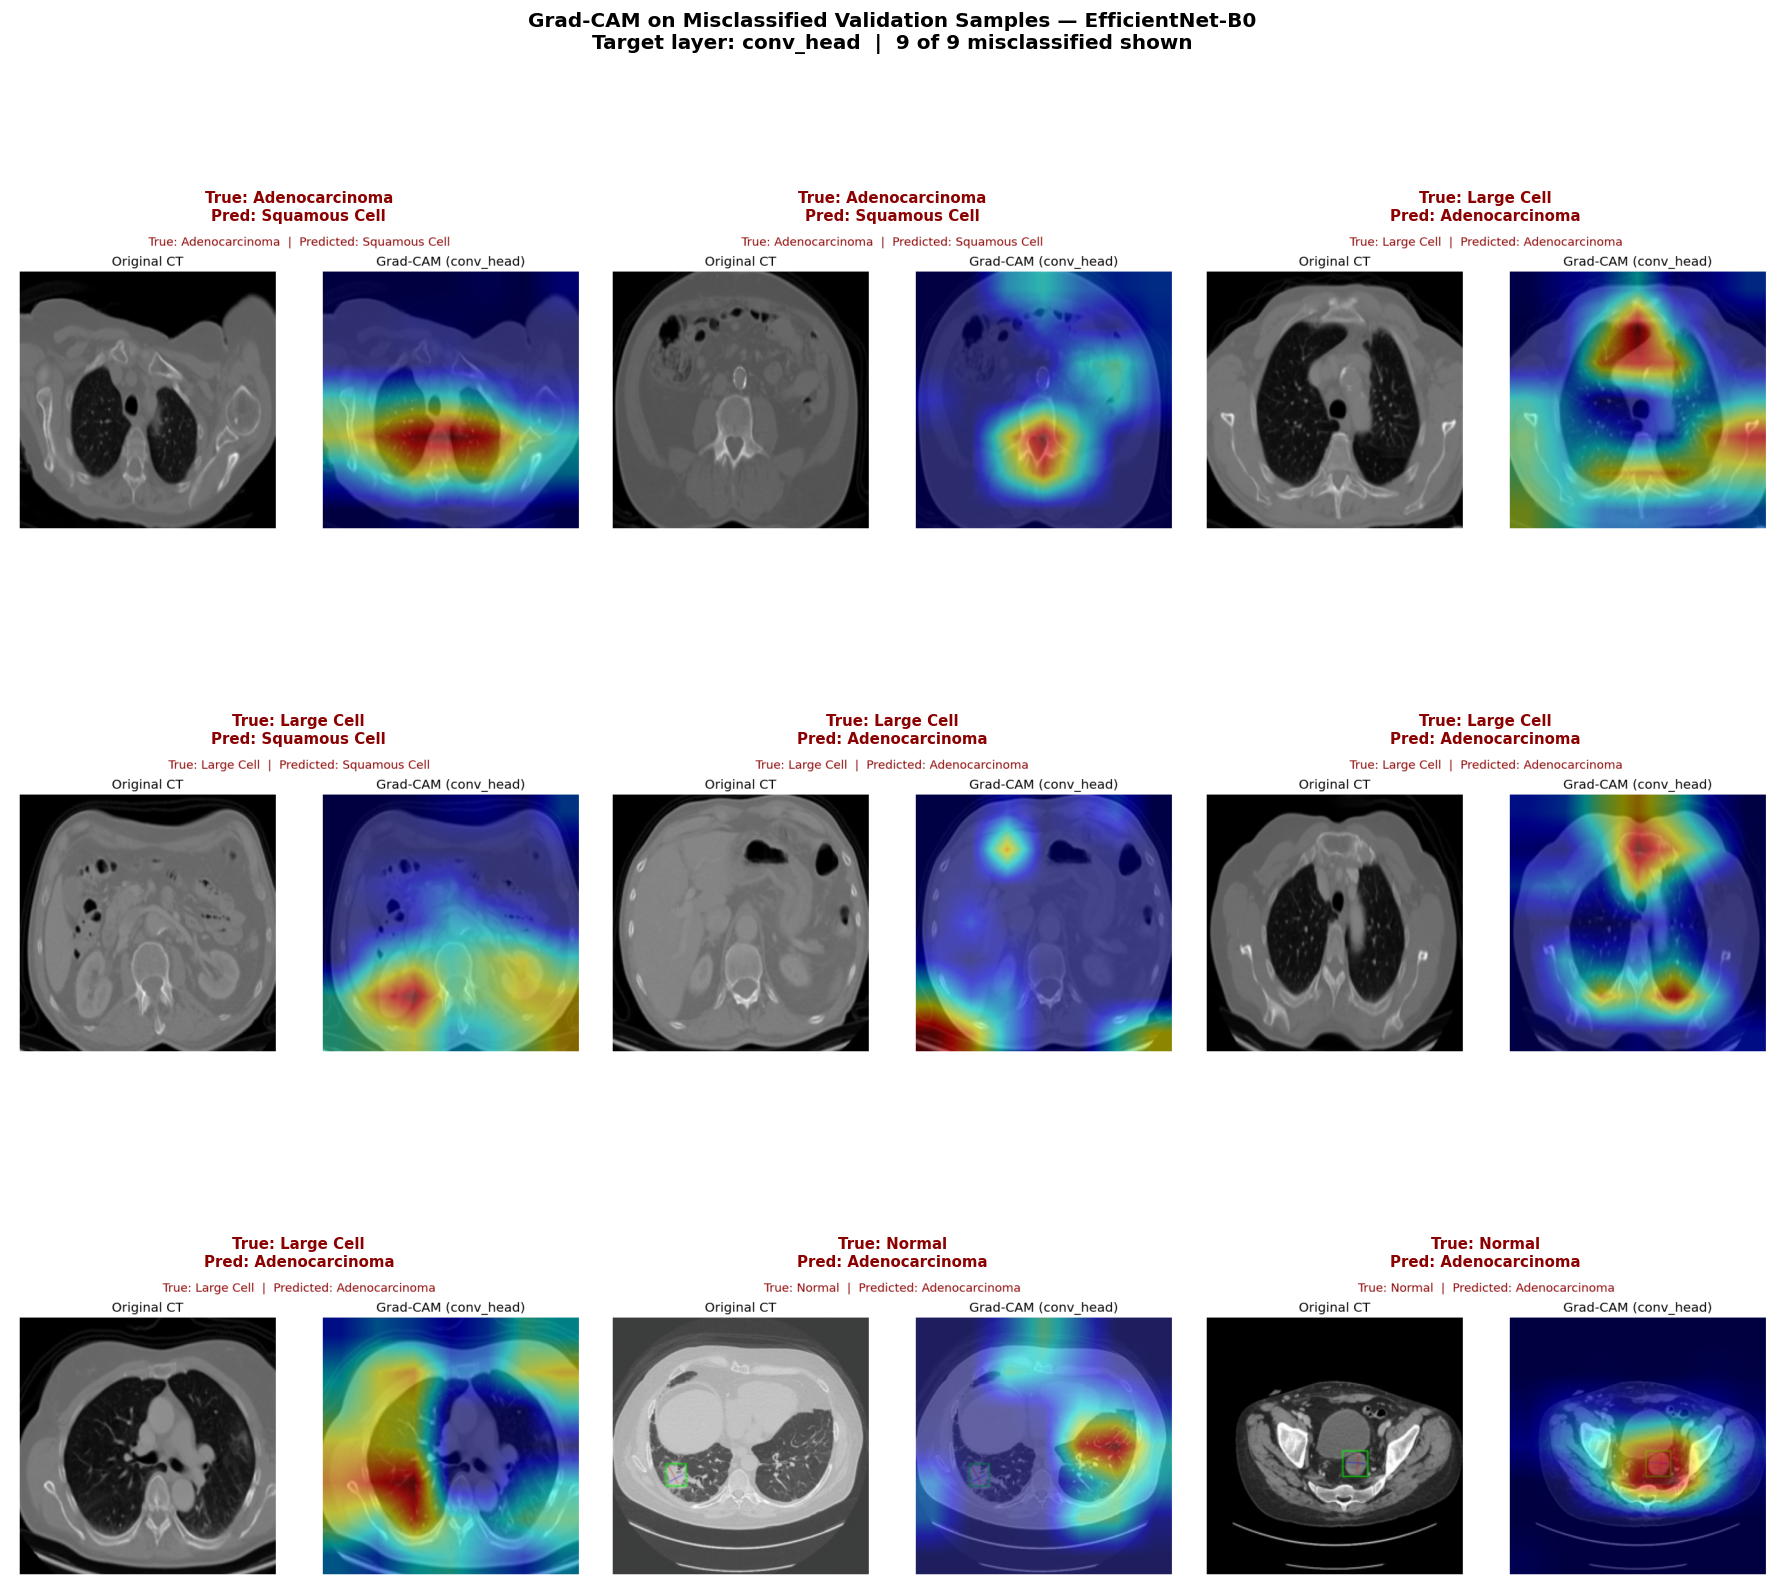


Misclassification patterns (validation set):
  Large Cell             predicted as  Adenocarcinoma          (4x)
  Adenocarcinoma         predicted as  Squamous Cell           (2x)
  Normal                 predicted as  Adenocarcinoma          (2x)
  Large Cell             predicted as  Squamous Cell           (1x)


In [10]:
samples = gradcam_summary['samples']
n = len(samples)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 5))
fig.suptitle(
    f'Grad-CAM on Misclassified Validation Samples — EfficientNet-B0\n'
    f'Target layer: {gradcam_summary["target_layer"]}  |  '
    f'{n} of {72 - int(run2_meta["best_val_acc"] * 72)} misclassified shown',
    fontsize=12, fontweight='bold'
)
axes = axes.flat

for ax, sample in zip(axes, samples):
    img_path = ROOT / sample['file']
    img = Image.open(img_path)
    ax.imshow(img)
    true_disp = DISPLAY_NAMES[sample['true']]
    pred_disp = DISPLAY_NAMES[sample['predicted']]
    ax.set_title(
        f'True: {true_disp}\nPred: {pred_disp}',
        fontsize=9,
        color='darkred',
        fontweight='bold'
    )
    ax.axis('off')

# Hide unused axes
for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()

# Pattern summary
from collections import Counter
patterns = Counter(f'{s["true"]} → {s["predicted"]}' for s in samples)
print('\nMisclassification patterns (validation set):')
for pattern, count in patterns.most_common():
    true_cls, pred_cls = pattern.split(' → ')
    print(f'  {DISPLAY_NAMES[true_cls]:<22} predicted as  {DISPLAY_NAMES[pred_cls]:<22}  ({count}x)')

## 8. Summary & Next Steps

In [11]:
# Run comparison summary
summary_data = [
    ('Backbone',            'ResNet-50',         'EfficientNet-B0'),
    ('Loss',                'Weighted CE',        'Focal (γ=2.0)'),
    ('Best Val Accuracy',   f'{run1_meta["best_val_acc"]:.2%}', f'{run2_meta["best_val_acc"]:.2%}'),
    ('Test Accuracy',       f'{run1_eval["test_accuracy"]:.2%}', f'{run2_eval["test_accuracy"]:.2%}'),
    ('Adeno Recall',
        f'{run1_eval["classification_report"]["Adenocarcinoma"]["recall"]:.2%}',
        f'{run2_eval["classification_report"]["Adenocarcinoma"]["recall"]:.2%}'),
    ('Normal F1',
        f'{run1_eval["classification_report"]["Normal"]["f1-score"]:.3f}',
        f'{run2_eval["classification_report"]["Normal"]["f1-score"]:.3f}'),
    ('Macro F1',
        f'{run1_eval["classification_report"]["macro avg"]["f1-score"]:.3f}',
        f'{run2_eval["classification_report"]["macro avg"]["f1-score"]:.3f}'),
    ('Training Time',
        f'{run1_meta["training_time_sec"]/3600:.1f}h',
        f'{run2_meta["training_time_sec"]/3600:.1f}h'),
]

df_summary = pd.DataFrame(summary_data, columns=['Metric', 'Run 1', 'Run 2'])
df_summary = df_summary.set_index('Metric')

display(df_summary.style
    .set_caption('Experiment Summary')
    .set_table_styles([{'selector': 'th', 'props': [('background-color', '#e8f4f8'), ('font-weight', 'bold')]}])
)

,Run 1,Run 2
Metric,,
Backbone,ResNet-50,EfficientNet-B0
Loss,Weighted CE,Focal (γ=2.0)
Best Val Accuracy,63.89%,87.50%
Test Accuracy,49.21%,73.97%
Adeno Recall,1.67%,50.83%
Normal F1,1.000,0.971
Macro F1,0.509,0.771
Training Time,2.7h,1.7h


### Key Findings

1. **EfficientNet-B0 + Focal Loss dramatically outperforms ResNet-50 + Weighted CE**
   - Test accuracy: 49.2% → 73.97% (+24.8pp)
   - Adenocarcinoma recall: 1.7% → 50.8% — focal loss fixed the class collapse
   - Training was also faster (~1.7h vs ~2.7h on CPU)

2. **Normal class is near-perfect (F1 = 0.97)** — the model reliably distinguishes healthy CT scans

3. **Main remaining challenge: Adenocarcinoma ↔ Squamous Cell confusion**
   - 53 of 120 adeno test samples misclassified as squamous
   - Grad-CAM shows the model activates on similar peripheral texture regions for both classes
   - This is a clinically known diagnostic challenge

4. **Val/Test gap (~13.5%)**: partly attributable to patient-level data leakage in the standard split

---

### Planned Improvements (Run 3)

| Improvement | Rationale |
|-------------|----------|
| **Two-phase fine-tuning** (freeze 8 epochs → unfreeze) | Small dataset: stabilise classifier head before full fine-tuning |
| **Label smoothing (ε=0.1)** | Penalise overconfident squamous predictions pulling adeno samples |
| **Larger input (299×299)** | CT nodule textures benefit from higher resolution |
| **Test-time augmentation (TTA)** | Average over 5 augmented versions — free +1–3% accuracy |

**Target:** Test accuracy > 80%, Adenocarcinoma recall > 65%